In [1]:
import tensorflow as tf

print("TensorFlow verzija:", tf.__version__)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU je dostupan:", gpu_devices)
else:
    print("GPU nije dostupan. Modeli će se trenirati na CPU-u, što može biti sporije.")

TensorFlow verzija: 2.21.0
GPU nije dostupan. Modeli će se trenirati na CPU-u, što može biti sporije.


In [2]:
from tensorflow.keras.datasets import cifar10

# Učitavanje CIFAR-10 skupa podataka
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Dimenzije trening slika:", x_train.shape)
print("Dimenzije trening oznaka:", y_train.shape)
print("Dimenzije testnih slika:", x_test.shape)
print("Dimenzije testnih oznaka:", y_test.shape)

Dimenzije trening slika: (50000, 32, 32, 3)
Dimenzije trening oznaka: (50000, 1)
Dimenzije testnih slika: (10000, 32, 32, 3)
Dimenzije testnih oznaka: (10000, 1)


c:\RVProjekt\.venv311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


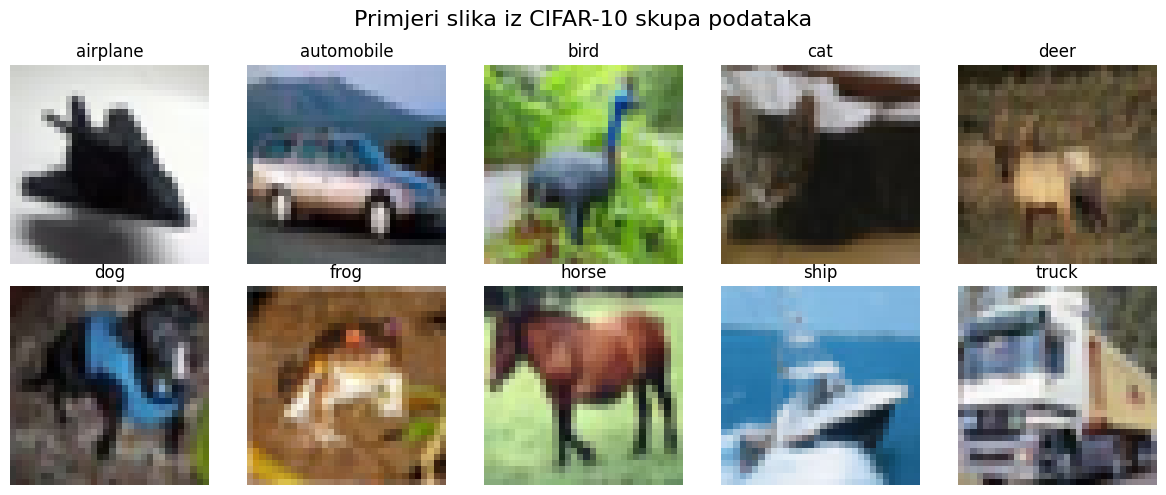

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Nazivi klasa u CIFAR-10 skupu podataka
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Prikaz po jedne slike iz svake klase
plt.figure(figsize=(12, 5))

for class_id in range(10):
    # pronađi prvi indeks slike koja pripada toj klasi
    index = np.where(y_train.flatten() == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.suptitle('Primjeri slika iz CIFAR-10 skupa podataka', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# Normalizacija vrijednosti piksela iz raspona 0-255 u raspon 0-1
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Najmanja vrijednost piksela nakon normalizacije:", x_train_norm.min())
print("Najveća vrijednost piksela nakon normalizacije:", x_train_norm.max())

Najmanja vrijednost piksela nakon normalizacije: 0.0
Najveća vrijednost piksela nakon normalizacije: 1.0


In [5]:
from tensorflow.keras.utils import to_categorical

# Pretvaranje oznaka klasa u one-hot encoding format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Originalna oznaka prve slike:", y_train[0])
print("One-hot oznaka prve slike:", y_train_cat[0])
print("Dimenzije y_train_cat:", y_train_cat.shape)
print("Dimenzije y_test_cat:", y_test_cat.shape)

Originalna oznaka prve slike: [6]
One-hot oznaka prve slike: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Dimenzije y_train_cat: (50000, 10)
Dimenzije y_test_cat: (10000, 10)


In [6]:
from sklearn.model_selection import train_test_split

# Podjela trening podataka na trening i validacijski skup
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_norm,
    y_train_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Trening slike:", x_train_final.shape)
print("Validacijske slike:", x_val.shape)
print("Trening oznake:", y_train_final.shape)
print("Validacijske oznake:", y_val.shape)

Trening slike: (40000, 32, 32, 3)
Validacijske slike: (10000, 32, 32, 3)
Trening oznake: (40000, 10)
Validacijske oznake: (10000, 10)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Definicija vlastitog CNN modela
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(10, activation='softmax')
])

# Kompilacija modela
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Prikaz strukture modela
cnn_model.summary()

c:\RVProjekt\.venv311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callback funkcije za stabilnije treniranje
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

# Treniranje vlastitog CNN modela
history_cnn = cnn_model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 131ms/step - accuracy: 0.4308 - loss: 1.6878 - val_accuracy: 0.5347 - val_loss: 1.3019 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.6055 - loss: 1.1078 - val_accuracy: 0.6771 - val_loss: 0.9211 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6712 - loss: 0.9269 - val_accuracy: 0.7077 - val_loss: 0.8269 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 127ms/step - accuracy: 0.7064 - loss: 0.8357 - val_accuracy: 0.7275 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 128ms/step - accuracy: 0.7337 - loss: 0.7543 - val_accuracy: 0.7272 - val_loss: 0.8039 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.7535 - loss: 0.7031 - val_accuracy: 0.7563 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.7

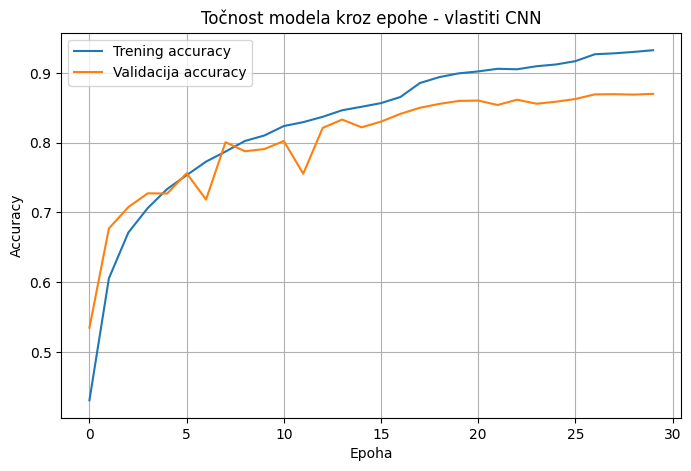

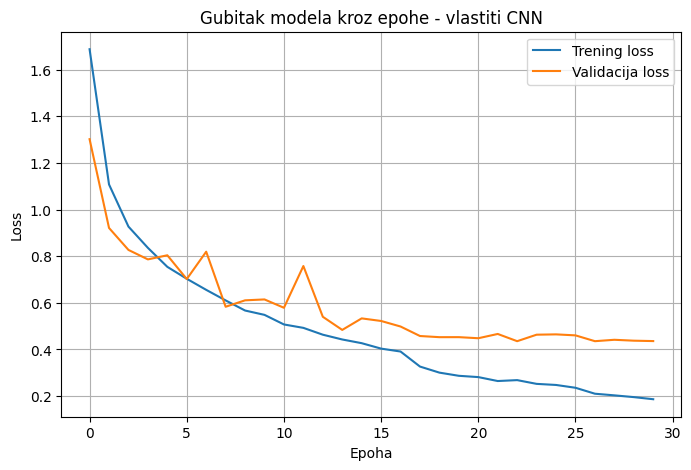

In [9]:
import matplotlib.pyplot as plt

# Graf točnosti (accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Trening accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validacija accuracy')
plt.title('Točnost modela kroz epohe - vlastiti CNN')
plt.xlabel('Epoha')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('cnn_accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Graf gubitka (loss)
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Trening loss')
plt.plot(history_cnn.history['val_loss'], label='Validacija loss')
plt.title('Gubitak modela kroz epohe - vlastiti CNN')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('cnn_loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Evaluacija na testnom skupu
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(x_test_norm, y_test_cat, verbose=0)

print("Test loss (CNN):", round(test_loss_cnn, 4))
print("Test accuracy (CNN):", round(test_acc_cnn, 4))

Test loss (CNN): 0.4757
Test accuracy (CNN): 0.8547


In [11]:
import numpy as np
from sklearn.metrics import classification_report

# Predikcije modela
y_pred_probs_cnn = cnn_model.predict(x_test_norm)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
y_true_cnn = y_test.flatten()

# Classification report
report_cnn = classification_report(y_true_cnn, y_pred_cnn, target_names=class_names)
print(report_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
              precision    recall  f1-score   support

    airplane       0.86      0.87      0.86      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.85      0.75      0.80      1000
         cat       0.74      0.70      0.72      1000
        deer       0.82      0.86      0.84      1000
         dog       0.79      0.78      0.78      1000
        frog       0.85      0.91      0.88      1000
       horse       0.90      0.89      0.89      1000
        ship       0.91      0.93      0.92      1000
       truck       0.89      0.92      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [12]:
from sklearn.metrics import accuracy_score

acc_check_cnn = accuracy_score(y_true_cnn, y_pred_cnn)

print("Provjera accuracy iz classification reporta:", round(acc_check_cnn, 4))
print("Accuracy iz model.evaluate():", round(test_acc_cnn, 4))

Provjera accuracy iz classification reporta: 0.8547
Accuracy iz model.evaluate(): 0.8547


<Figure size 1000x800 with 0 Axes>

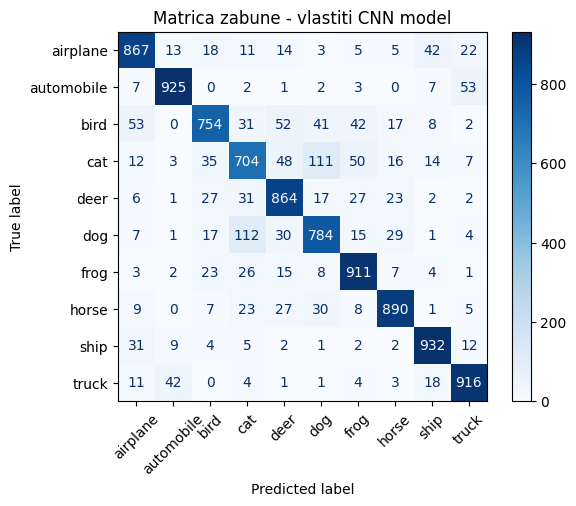

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrica zabune
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matrica zabune - vlastiti CNN model')
plt.savefig('cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_cnn = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
recall_cnn = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
f1_cnn = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print("CNN Accuracy :", round(test_acc_cnn, 4))
print("CNN Precision:", round(precision_cnn, 4))
print("CNN Recall   :", round(recall_cnn, 4))
print("CNN F1-score :", round(f1_cnn, 4))

CNN Accuracy : 0.8547
CNN Precision: 0.8541
CNN Recall   : 0.8547
CNN F1-score : 0.8539


In [15]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Ulazni sloj za CIFAR-10 slike 32x32x3
inputs = Input(shape=(32, 32, 3))

# Povećanje slike na 96x96 jer ResNet50 bolje radi s većim slikama
x = Resizing(96, 96)(inputs)

# ResNet50 preprocessing
x = preprocess_input(x * 255.0)

# Učitavanje ResNet50 modela bez završnog klasifikacijskog sloja
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Zamrzavanje osnovnog ResNet50 modela
base_model.trainable = False

# Prolazak kroz ResNet50 bazu
x = base_model(x, training=False)

# Dodavanje vlastitog klasifikacijskog dijela
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Izlazni sloj za 10 CIFAR-10 klasa
outputs = Dense(10, activation='softmax')(x)

# Konačni model
resnet_model = Model(inputs, outputs)

# Kompilacija modela
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Prikaz strukture modela
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 96, 96, 3) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 96, 96, 3) │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 3, 3,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping - zaustavlja treniranje ako se validacijski loss ne poboljšava
early_stop_resnet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Smanjuje learning rate ako model zapne
reduce_lr_resnet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

# Treniranje ResNet50 modela
history_resnet = resnet_model.fit(
    x_train_final,
    y_train_final,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_resnet, reduce_lr_resnet],
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 389s 614ms/step - accuracy: 0.7763 - loss: 0.6900 - val_accuracy: 0.8382 - val_loss: 0.4654 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 370s 593ms/step - accuracy: 0.8317 - loss: 0.4988 - val_accuracy: 0.8562 - val_loss: 0.4220 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 384s 615ms/step - accuracy: 0.8468 - loss: 0.4434 - val_accuracy: 0.8560 - val_loss: 0.4250 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 390s 624ms/step - accuracy: 0.8568 - loss: 0.4110 - val_accuracy: 0.8615 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 386s 617ms/step - accuracy: 0.8669 - loss: 0.3823 - val_accuracy: 0.8638 - val_loss: 0.4142 - learning_rate: 0.0010
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 392s 627ms/step - accuracy: 0.8723 - loss: 0.3589 - val_accuracy: 0.8663 - val_loss: 0.4185 - learning_rate: 0.0010
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 370s 592ms/step - accura

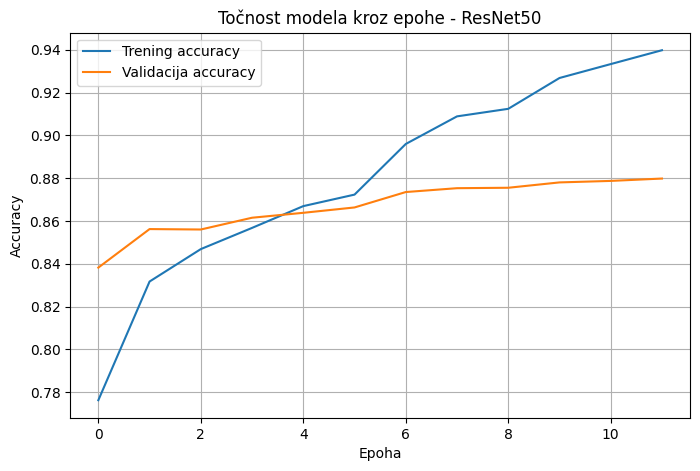

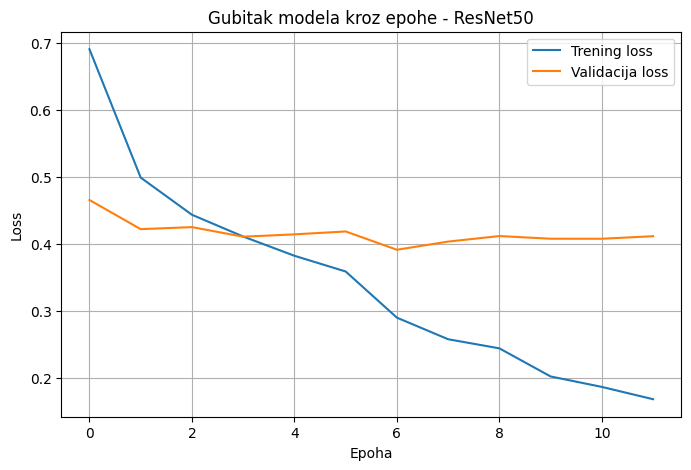

In [17]:
# Graf točnosti (accuracy) za ResNet50
plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['accuracy'], label='Trening accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validacija accuracy')
plt.title('Točnost modela kroz epohe - ResNet50')
plt.xlabel('Epoha')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('resnet_accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Graf gubitka (loss) za ResNet50
plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['loss'], label='Trening loss')
plt.plot(history_resnet.history['val_loss'], label='Validacija loss')
plt.title('Gubitak modela kroz epohe - ResNet50')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('resnet_loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Evaluacija ResNet50 modela na testnom skupu
test_loss_resnet, test_acc_resnet = resnet_model.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=1
)

print("Test loss (ResNet50):", round(test_loss_resnet, 4))
print("Test accuracy (ResNet50):", round(test_acc_resnet, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.8724 - loss: 0.3900
Test loss (ResNet50): 0.39
Test accuracy (ResNet50): 0.8724


### Rezultati treniranja ResNet50 modela

ResNet50 model treniran je korištenjem transfer learning pristupa. Predtrenirana ResNet50 baza učitana je s ImageNet težinama, dok je završni klasifikacijski dio prilagođen za klasifikaciju CIFAR-10 skupa podataka.

Model je bio planiran za treniranje kroz 15 epoha, ali je treniranje zaustavljeno nakon 12 epoha zbog EarlyStopping mehanizma. Budući da je korišten parametar restore_best_weights=True, nakon zaustavljanja zadržane su težine iz epohe u kojoj je model ostvario najbolji validacijski gubitak.

Validacijski rezultati korišteni su za praćenje procesa treniranja i podešavanje modela, dok je konačna procjena generalizacije provedena na odvojenom testnom skupu.

In [23]:
# Classification report za ResNet50 na testnom skupu
y_pred_probs_resnet = resnet_model.predict(x_test_norm)
y_pred_resnet = np.argmax(y_pred_probs_resnet, axis=1)
y_true_resnet = y_test.flatten()

report_resnet = classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=class_names
)

print(report_resnet)

313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 273ms/step
              precision    recall  f1-score   support

    airplane       0.87      0.90      0.89      1000
  automobile       0.91      0.93      0.92      1000
        bird       0.90      0.84      0.87      1000
         cat       0.75      0.78      0.76      1000
        deer       0.83      0.85      0.84      1000
         dog       0.83      0.79      0.81      1000
        frog       0.89      0.92      0.90      1000
       horse       0.91      0.89      0.90      1000
        ship       0.92      0.92      0.92      1000
       truck       0.92      0.89      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_resnet = precision_score(y_true_resnet, y_pred_resnet, average='weighted')
recall_resnet = recall_score(y_true_resnet, y_pred_resnet, average='weighted')
f1_resnet = f1_score(y_true_resnet, y_pred_resnet, average='weighted')

print("ResNet50 Accuracy :", round(test_acc_resnet, 4))
print("ResNet50 Precision:", round(precision_resnet, 4))
print("ResNet50 Recall   :", round(recall_resnet, 4))
print("ResNet50 F1-score :", round(f1_resnet, 4))

ResNet50 Accuracy : 0.8724
ResNet50 Precision: 0.8732
ResNet50 Recall   : 0.8724
ResNet50 F1-score : 0.8725


In [26]:
import pandas as pd

# Konačna usporedba modela na testnom skupu
comparison_test_data = {
    "Model": ["Vlastiti CNN", "ResNet50"],
    "Test accuracy": [test_acc_cnn, test_acc_resnet],
    "Test loss": [test_loss_cnn, test_loss_resnet],
    "Precision": [precision_cnn, precision_resnet],
    "Recall": [recall_cnn, recall_resnet],
    "F1-score": [f1_cnn, f1_resnet]
}

comparison_test_df = pd.DataFrame(comparison_test_data)

# Zaokruživanje vrijednosti na 4 decimale
comparison_test_df_rounded = comparison_test_df.copy()
for col in ["Test accuracy", "Test loss", "Precision", "Recall", "F1-score"]:
    comparison_test_df_rounded[col] = comparison_test_df_rounded[col].round(4)

comparison_test_df_rounded

,Model,Test accuracy,Test loss,Precision,Recall,F1-score
0,Vlastiti CNN,0.8547,0.4757,0.8541,0.8547,0.8539
1,ResNet50,0.8724,0.3900,0.8732,0.8724,0.8725


## Analiza usporedbe modela na testnom skupu

Konačna usporedba vlastitog CNN modela i ResNet50 modela provedena je na odvojenom testnom skupu koji nije korišten tijekom treniranja ni tijekom podešavanja modela. Time se dobiva realnija procjena generalizacije modela na nove, prethodno neviđene podatke.

Vlastiti CNN model ostvario je testnu točnost od 85,47 %, testni gubitak 0,4757, precision 0,8541, recall 0,8547 i F1-score 0,8539. ResNet50 model ostvario je testnu točnost od 87,24 %, testni gubitak 0,3900, precision 0,8732, recall 0,8724 i F1-score 0,8725.

Na temelju testnih rezultata može se zaključiti da je ResNet50 model ostvario bolje performanse od vlastitog CNN modela. Razlika u testnoj točnosti iznosi približno 1,77 postotnih bodova u korist ResNet50 modela. Osim veće točnosti, ResNet50 je ostvario i manji testni gubitak, što upućuje na stabilnije predikcije na testnom skupu.

Ipak, razlika između modela nije izrazito velika. Vlastiti CNN model pokazao je vrlo solidne rezultate, osobito s obzirom na to da je treniran od početka samo na CIFAR-10 skupu podataka. ResNet50 prednost ostvaruje zahvaljujući prijenosnom učenju i prethodno naučenim značajkama iz ImageNet skupa podataka.

Analiza matrica zabune pokazuje da oba modela najviše griješe kod vizualno sličnih klasa, posebno kod klasa cat i dog. Takve pogreške su očekivane jer CIFAR-10 slike imaju nisku rezoluciju od 32×32 piksela, zbog čega su fine vizualne razlike između sličnih objekata ograničeno vidljive.

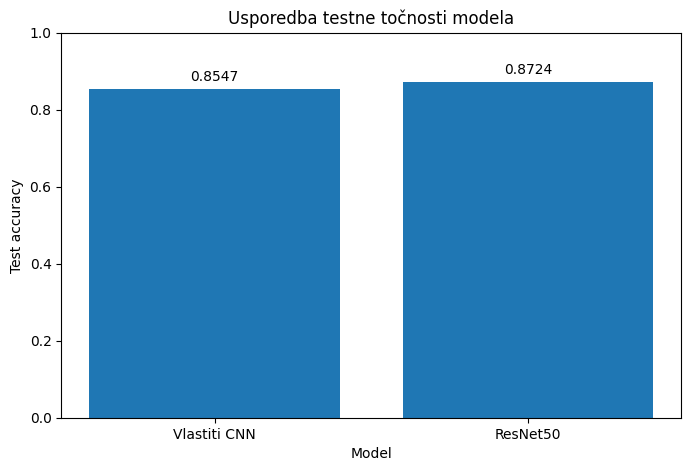

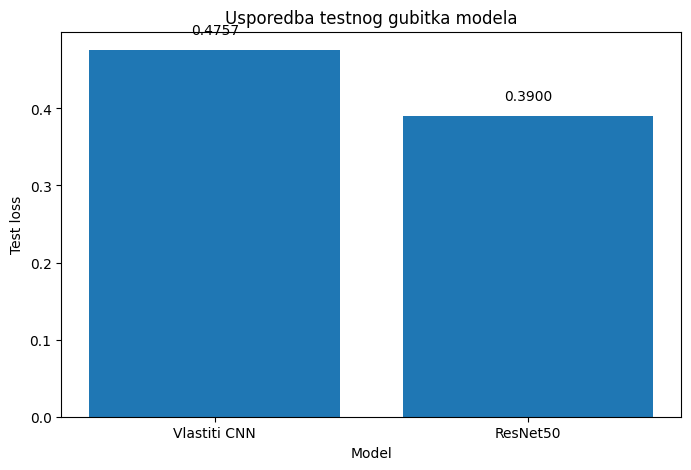

In [27]:
# Graf usporedbe testne točnosti modela
plt.figure(figsize=(8, 5))
plt.bar(comparison_test_df_rounded["Model"], comparison_test_df_rounded["Test accuracy"])
plt.title("Usporedba testne točnosti modela")
plt.xlabel("Model")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)

for i, value in enumerate(comparison_test_df_rounded["Test accuracy"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.savefig("test_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Graf usporedbe testnog gubitka modela
plt.figure(figsize=(8, 5))
plt.bar(comparison_test_df_rounded["Model"], comparison_test_df_rounded["Test loss"])
plt.title("Usporedba testnog gubitka modela")
plt.xlabel("Model")
plt.ylabel("Test loss")

for i, value in enumerate(comparison_test_df_rounded["Test loss"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.savefig("test_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Zaključak eksperimentalnog dijela

U eksperimentalnom dijelu rada implementirana su i evaluirana dva modela za klasifikaciju objekata na CIFAR-10 skupu podataka: vlastiti CNN model i ResNet50 model korišten metodom prijenosnog učenja.

Podaci su jasno podijeljeni na trening, validacijski i testni skup. Trening skup korišten je za učenje modela, validacijski skup za praćenje procesa treniranja i podešavanje modela, dok je testni skup korišten isključivo za konačnu evaluaciju generalizacije modela.

Vlastiti CNN model ostvario je testnu točnost od 85,47 %, testni gubitak 0,4757, precision 0,8541, recall 0,8547 i F1-score 0,8539. ResNet50 model ostvario je testnu točnost od 87,24 %, testni gubitak 0,3900, precision 0,8732, recall 0,8724 i F1-score 0,8725.

Na temelju testnih rezultata može se zaključiti da je ResNet50 model ostvario nešto bolje performanse od vlastitog CNN modela. Razlika u testnoj točnosti iznosi približno 1,77 postotnih bodova. ResNet50 je također ostvario manji testni gubitak, što upućuje na stabilnije predikcije.

Analiza matrica zabune pokazala je da oba modela najviše griješe kod vizualno sličnih klasa, posebno kod klasa cat i dog. Takav rezultat je očekivan zbog niske rezolucije CIFAR-10 slika od 32×32 piksela.

Zaključno, ResNet50 model pokazao se nešto uspješnijim zbog korištenja prijenosnog učenja i prethodno naučenih značajki iz ImageNet skupa podataka, dok je vlastiti CNN model ostvario vrlo dobre rezultate s obzirom na jednostavniju arhitekturu i treniranje od početka.